# BGE Embeddings + TensorFlow MLP — Sentiment Classification
Run each cell one at a time to isolate where the error occurs.

## Cell 1 — Environment flags (must run before any other import)

In [1]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"]   = ""
os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "2"

print("Environment flags set")

Environment flags set


## Cell 2 — Standard library imports

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Standard imports OK")

Standard imports OK


## Cell 3 — Load data

In [3]:
DATA_PATH = Path("./data/reviews.csv")

df = pd.read_csv(DATA_PATH, usecols=["Review Text", "Rating"]).dropna()
df = df[df["Rating"] != 3]
df["label"] = (df["Rating"] >= 4).astype(int)

X = df["Review Text"].astype(str)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Label balance (train): {y_train.value_counts().to_dict()}")

Train: 15,854  |  Test: 3,964
Label balance (train): {1: 13958, 0: 1896}


## Cell 4 — Import sentence-transformers

In [4]:
from sentence_transformers import SentenceTransformer

print("sentence-transformers imported OK")

sentence-transformers imported OK


## Cell 5 — Load BGE encoder (device=cpu to avoid Metal/MPS mutex bug)

In [5]:
encoder = SentenceTransformer("BAAI/bge-base-en-v1.5", device="cpu")

print("Encoder loaded OK")

Encoder loaded OK


## Cell 6 — Generate BGE embeddings

In [6]:
print("Embedding training set...")
X_train_bge = encoder.encode(
    X_train.tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)

print("Embedding test set...")
X_test_bge = encoder.encode(
    X_test.tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64,
)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print(f"X_train_bge shape: {X_train_bge.shape}")
print(f"X_test_bge shape : {X_test_bge.shape}")

## Cell 7 — Import TensorFlow

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Cell 8 — Build MLP model

In [8]:
input_dim = X_train_bge.shape[1]

mlp_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

mlp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

mlp_model.summary()

 Non-trainable params: 0 (0.00 B)

## Cell 9 — Train

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

history = mlp_model.fit(
    X_train_bge,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
)

397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step - accuracy: 0.9695 - loss: 0.0798 - precision: 0.9810 - recall: 0.9844 - val_accuracy: 0.9650 - val_loss: 0.0917 - val_precision: 0.9802 - val_recall: 0.9798


## Cell 10 — Evaluate

In [10]:
y_prob = mlp_model.predict(X_test_bge).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9598890010090817

              precision    recall  f1-score   support

    negative       0.85      0.81      0.83       474
    positive       0.97      0.98      0.98      3490

    accuracy                           0.96      3964
   macro avg       0.91      0.89      0.90      3964
weighted avg       0.96      0.96      0.96      3964


Confusion Matrix:
[[ 382   92]
 [  67 3423]]


## Cell 11 — Save model

In [12]:
import joblib
import sys
sys.path.insert(0, str(Path("../../../").resolve()))

KERAS_MODEL_PATH = Path("./model/sentiment_model_bge_mlp.keras")
WRAPPER_PATH     = Path("./model/sentiment_model_bge_mlp.joblib")

mlp_model.save(KERAS_MODEL_PATH)
print(f"Keras model saved to: {KERAS_MODEL_PATH}")

from app.training.bge_mlp_model import BGEMLPModel

wrapper = BGEMLPModel(
    encoder_name="BAAI/bge-base-en-v1.5",
    keras_model_path=str(KERAS_MODEL_PATH.resolve()),
)
joblib.dump(wrapper, WRAPPER_PATH)
print(f"Wrapper saved to    : {WRAPPER_PATH}")

Keras model saved to: model/sentiment_model_bge_mlp.keras
Wrapper saved to    : model/sentiment_model_bge_mlp.joblib


## Cell 12 — Training history plot

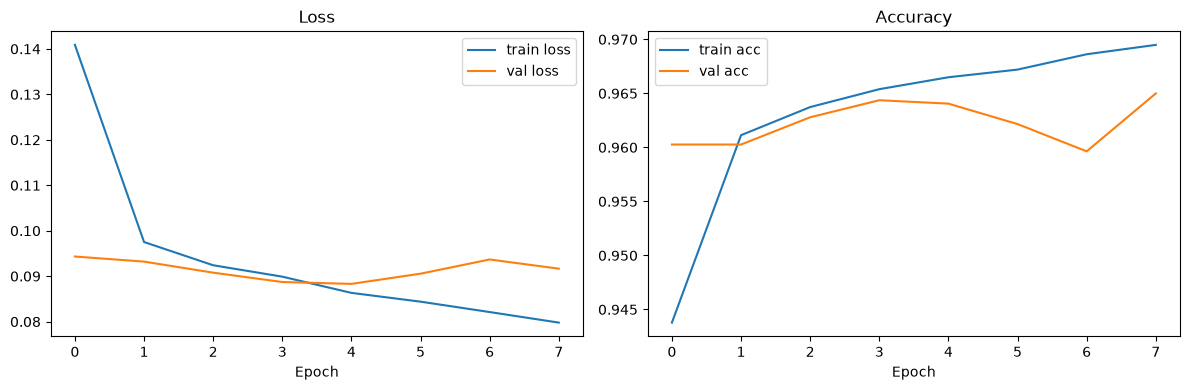

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()